In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve

In [2]:
plt.style.use("seaborn-v0_8-paper")

sns.set_context("notebook")
sns.set_palette("deep")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.info()

Train shape: (593994, 13)
Test shape: (254569, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9

In [5]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,593994.0,296996.500000,171471.442235,0.000,148498.250,296996.500,445494.750,593993.000
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


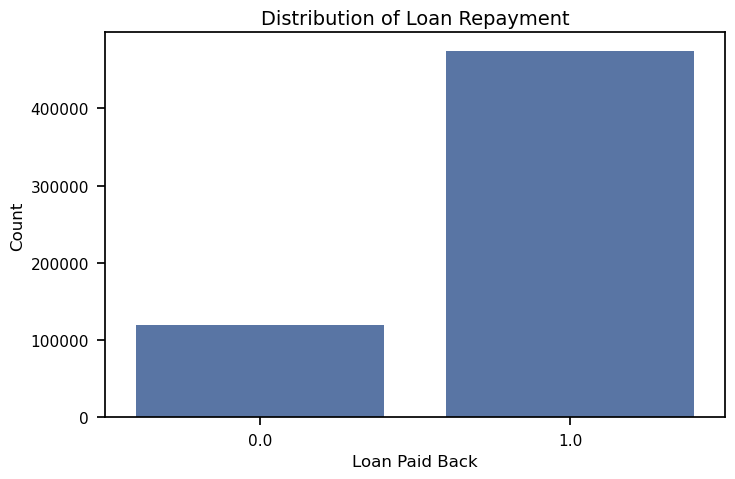

In [6]:
plt.figure()

sns.countplot(
    x="loan_paid_back",
    data=train
)

plt.title("Distribution of Loan Repayment")
plt.xlabel("Loan Paid Back")
plt.ylabel("Count")

plt.show()

In [7]:
num_cols = [
    "annual_income",
    "debt_to_income_ratio",
    "credit_score",
    "loan_amount",
    "interest_rate"
]

cat_cols = [
    "gender",
    "marital_status",
    "education_level",
    "employment_status",
    "loan_purpose",
    "grade_subgrade"
]

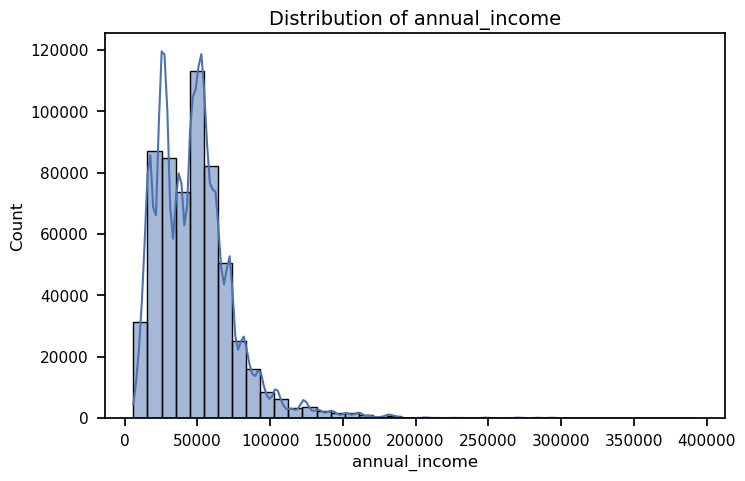

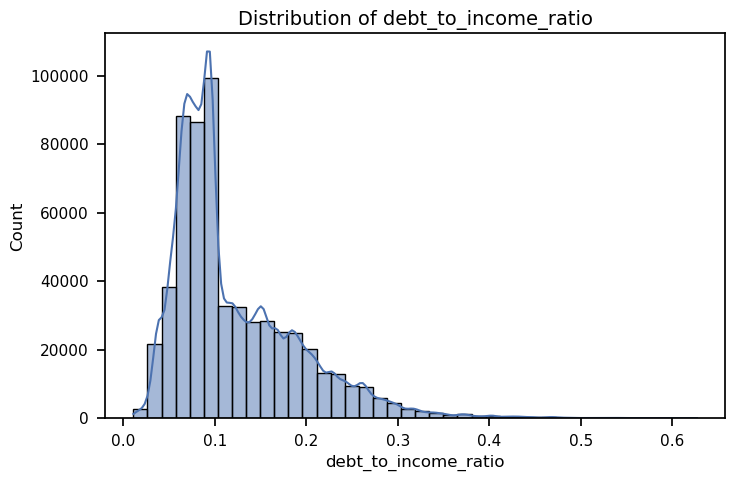

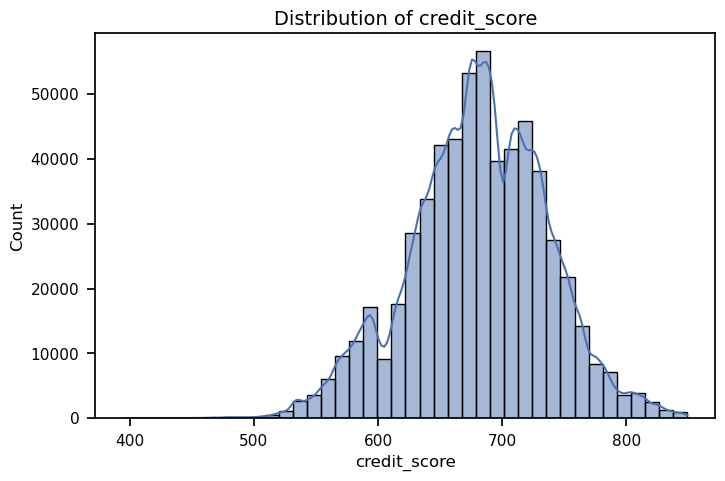

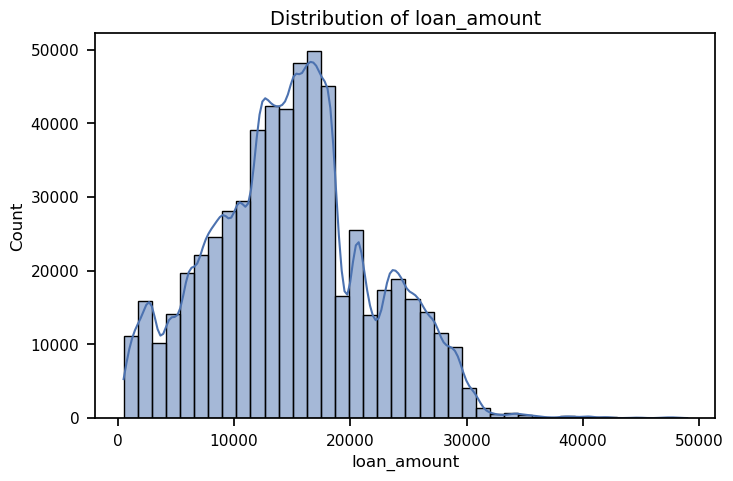

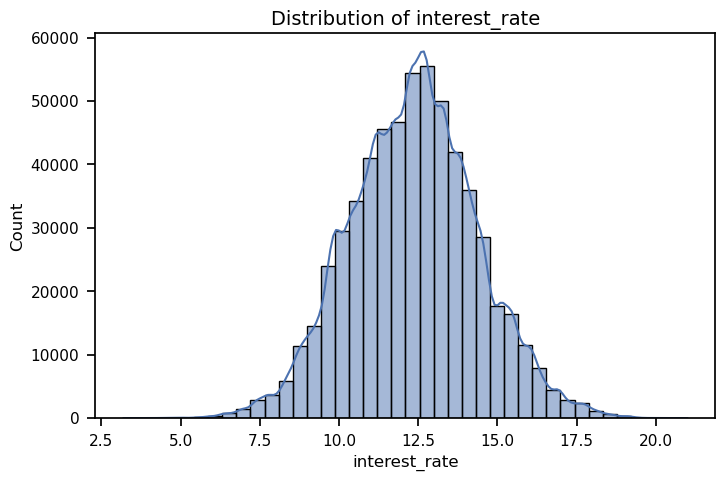

In [8]:
for col in num_cols:

    plt.figure()

    sns.histplot(
        train[col],
        bins=40,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

    plt.show()

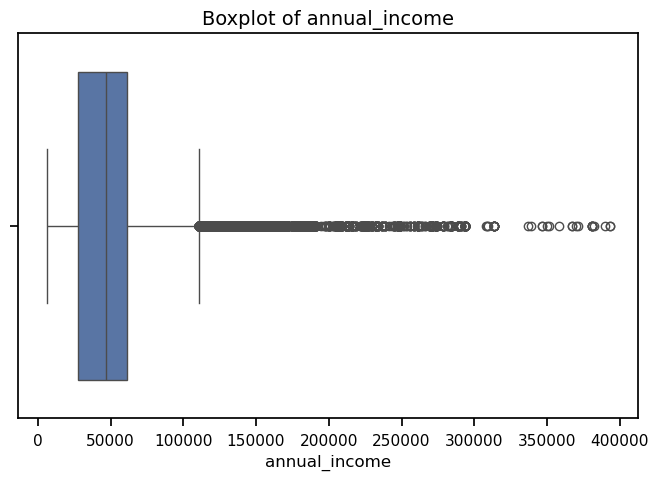

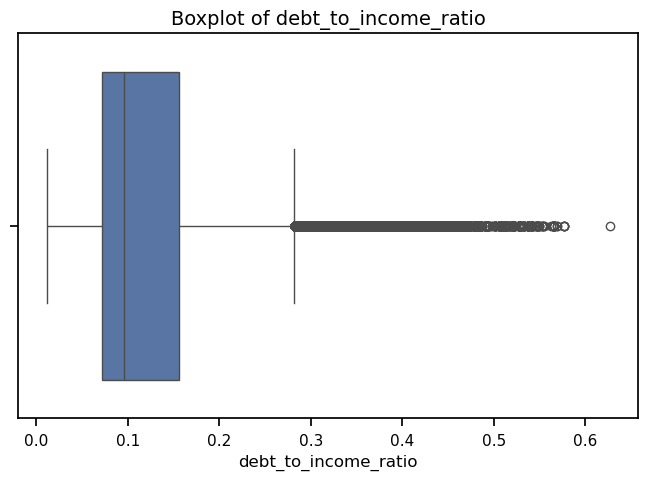

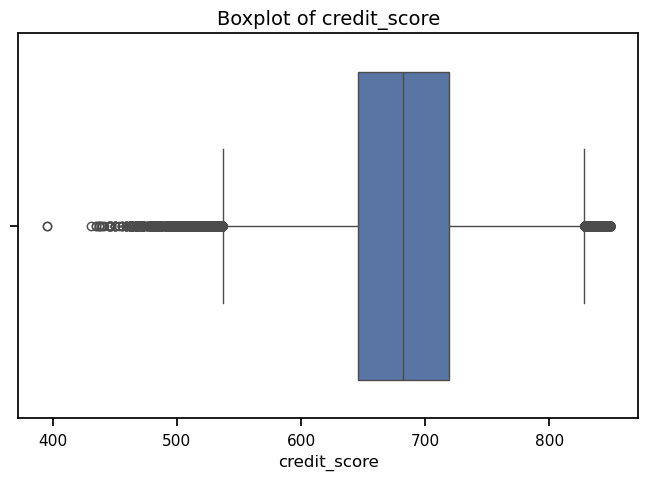

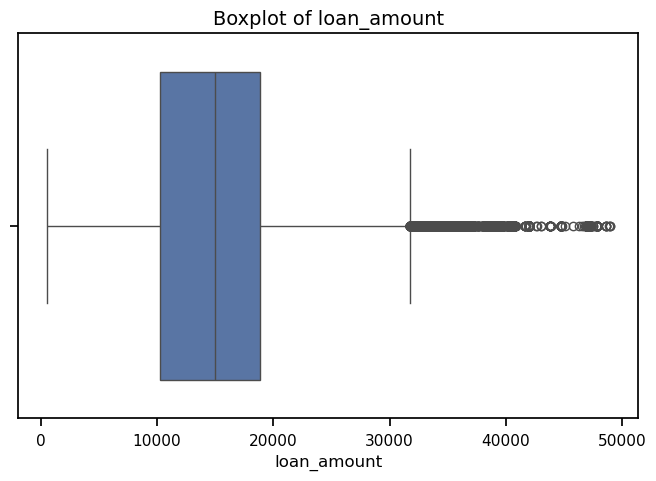

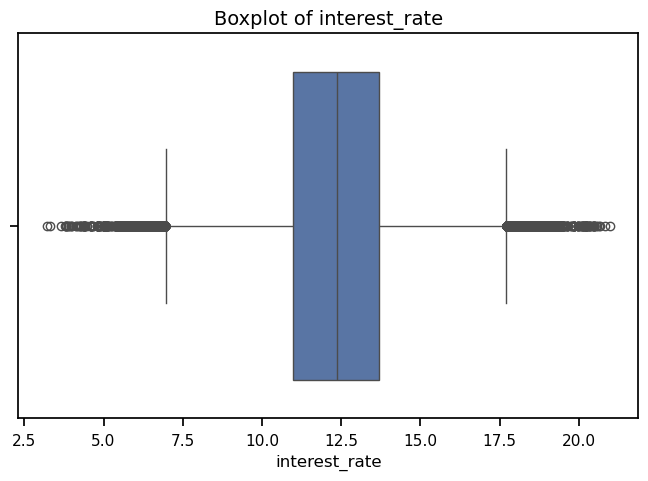

In [9]:
for col in num_cols:

    plt.figure()

    sns.boxplot(x=train[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

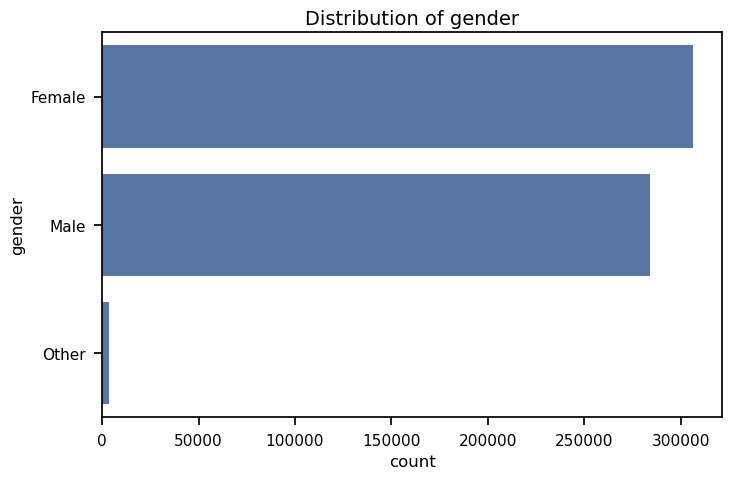

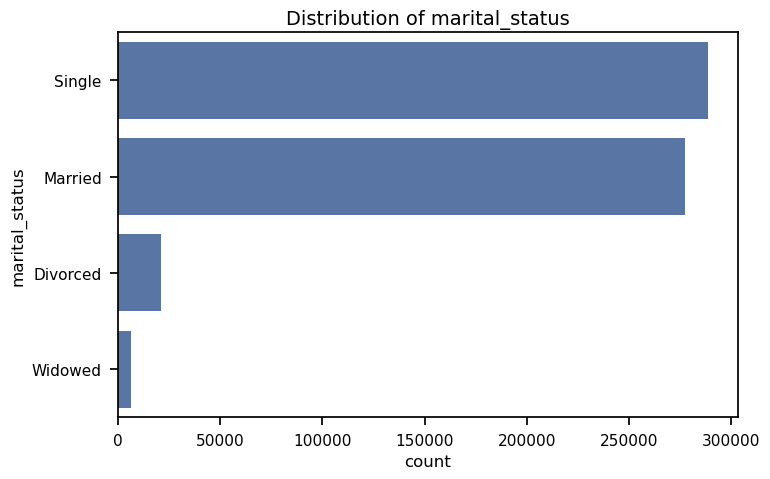

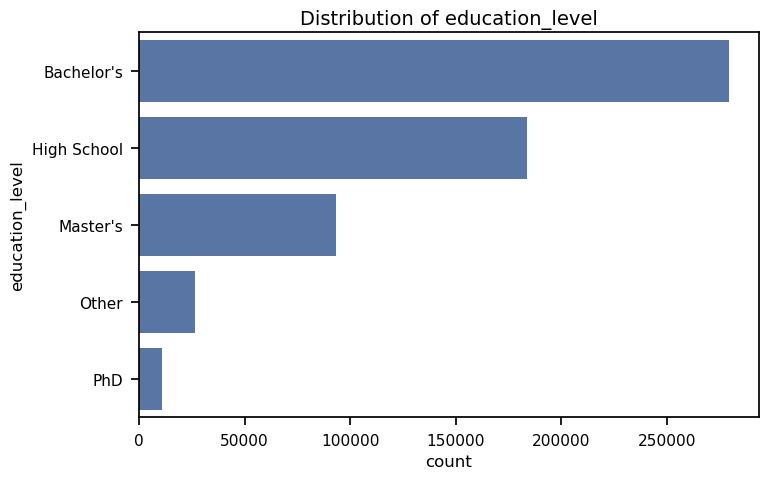

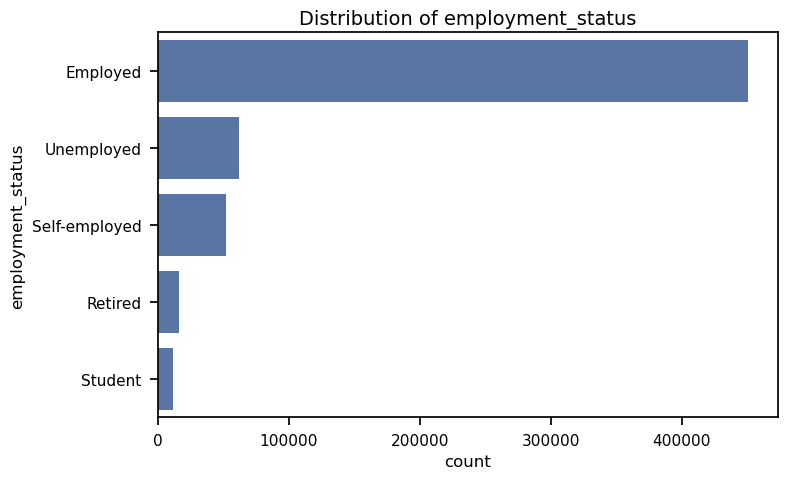

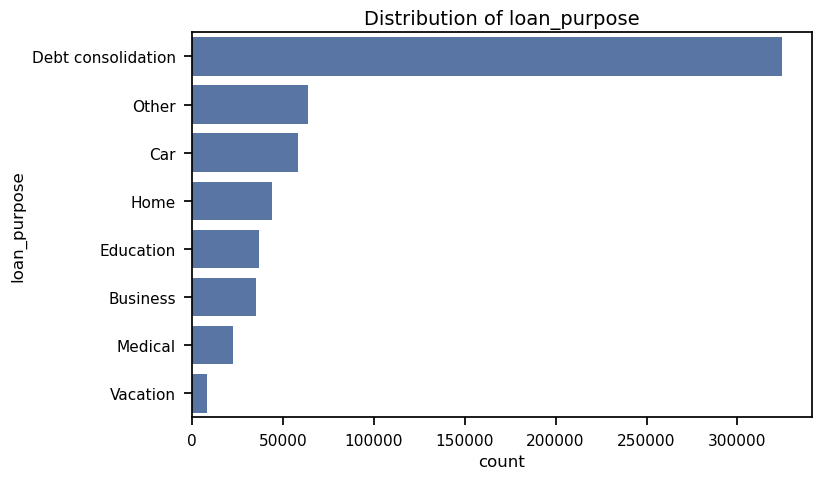

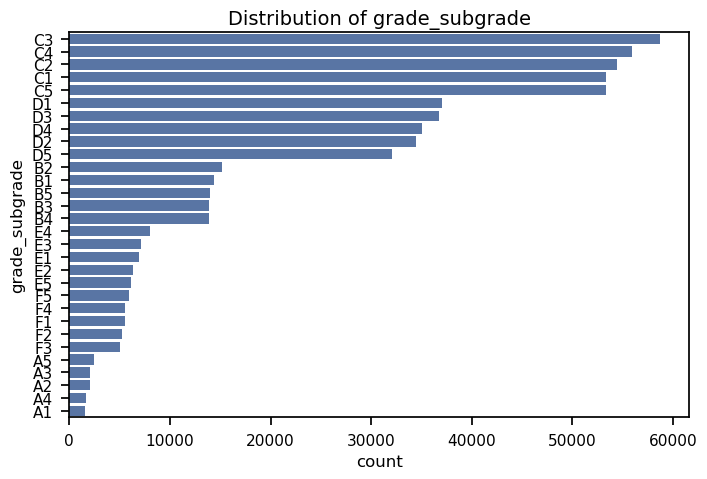

In [10]:
for col in cat_cols:

    plt.figure()

    sns.countplot(
        y=train[col],
        order=train[col].value_counts().index
    )

    plt.title(f"Distribution of {col}")

    plt.show()

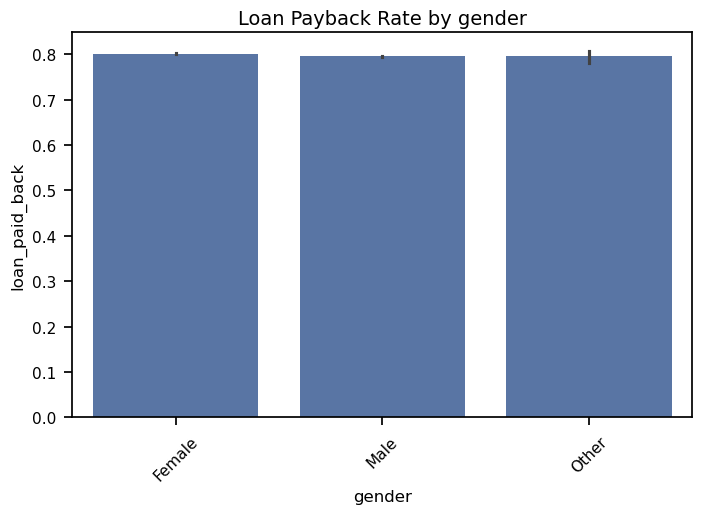

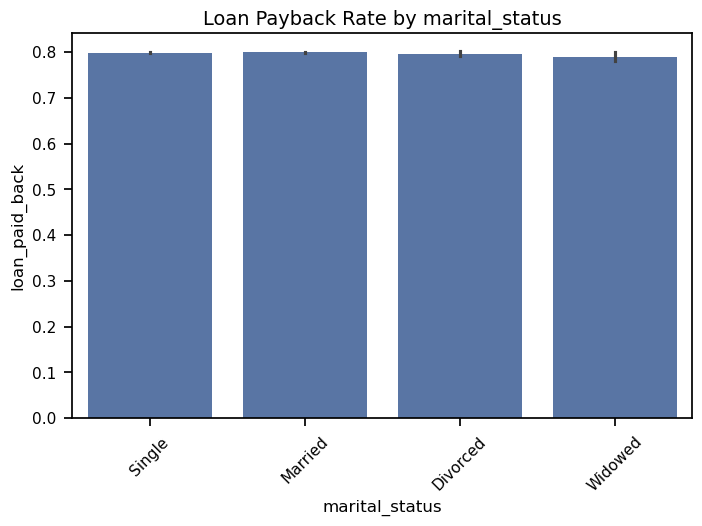

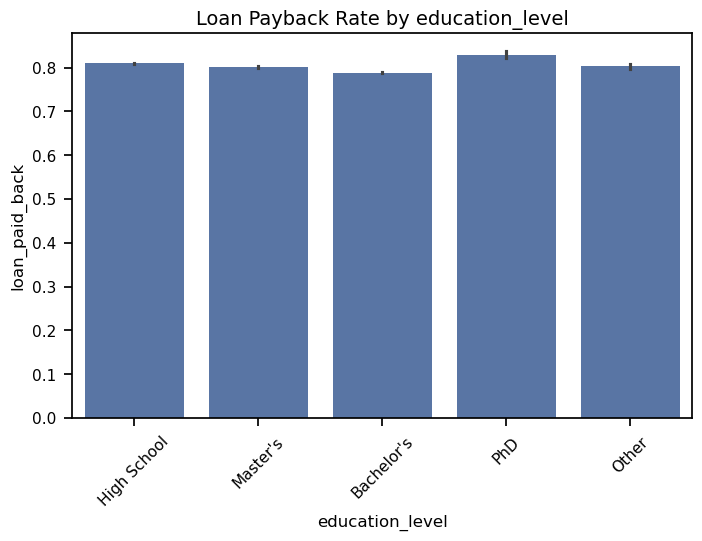

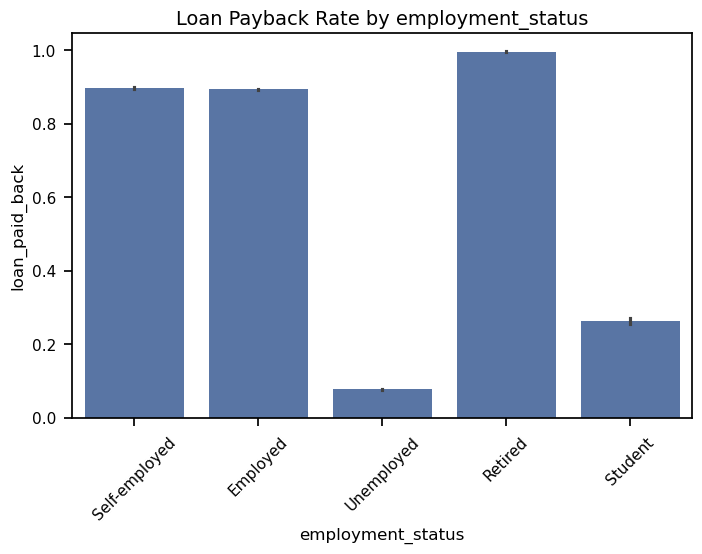

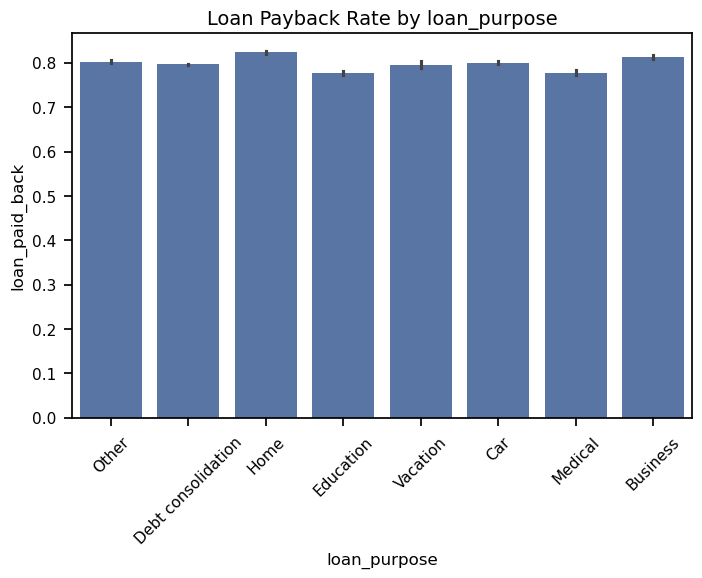

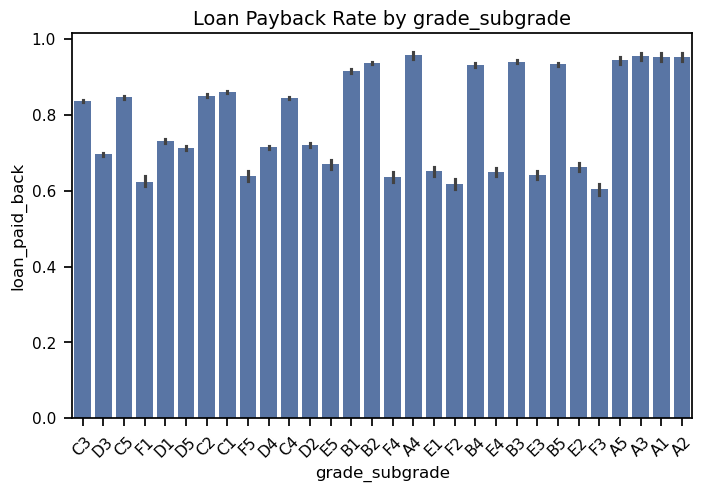

In [11]:
for col in cat_cols:

    plt.figure()

    sns.barplot(
        x=col,
        y="loan_paid_back",
        data=train
    )

    plt.title(f"Loan Payback Rate by {col}")

    plt.xticks(rotation=45)

    plt.show()

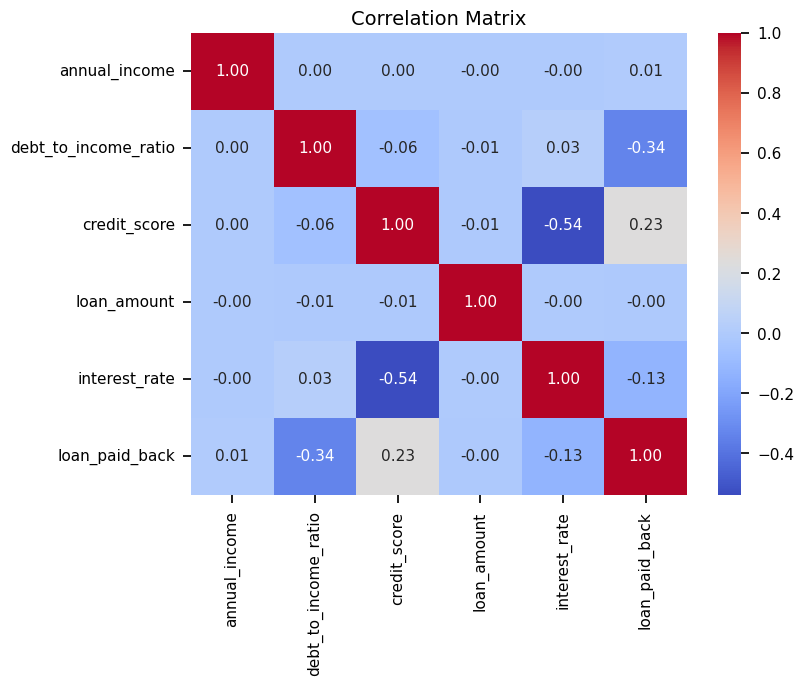

In [12]:
corr = train[num_cols + ["loan_paid_back"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

C:\Users\Utkarsh Sharma\AppData\Local\Temp\ipykernel_16376\951220934.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = train.groupby("credit_score_bin")["loan_paid_back"].mean()


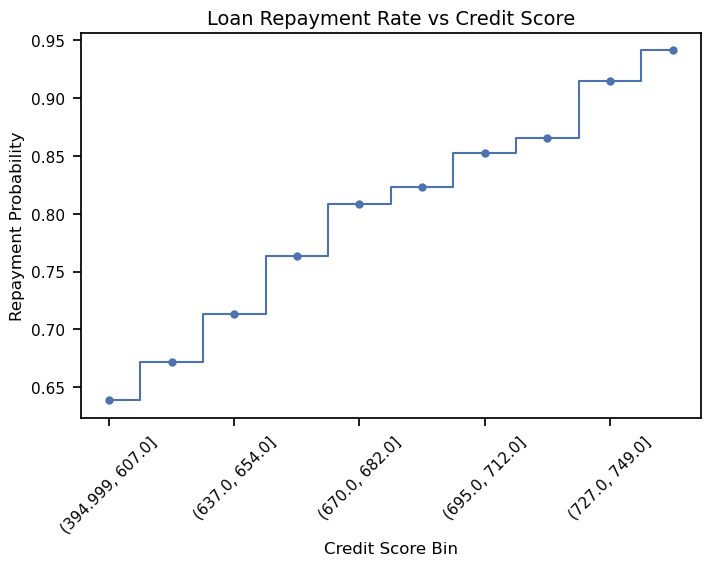

In [13]:
plt.figure()

train["credit_score_bin"] = pd.qcut(train["credit_score"], q=10)

risk = train.groupby("credit_score_bin")["loan_paid_back"].mean()

risk.plot(
    kind="line",
    marker="o",
    drawstyle="steps-mid"
)

plt.title("Loan Repayment Rate vs Credit Score")
plt.xlabel("Credit Score Bin")
plt.ylabel("Repayment Probability")

plt.xticks(rotation=45)

plt.show()

C:\Users\Utkarsh Sharma\AppData\Local\Temp\ipykernel_16376\1453486949.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = train.groupby("dti_bin")["loan_paid_back"].mean()


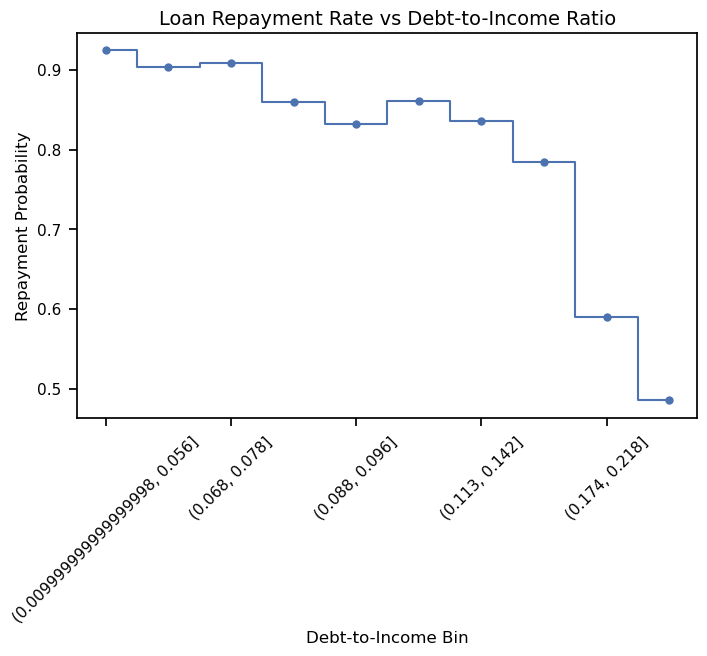

In [14]:
plt.figure()

train["dti_bin"] = pd.qcut(train["debt_to_income_ratio"], q=10)

risk = train.groupby("dti_bin")["loan_paid_back"].mean()

risk.plot(
    kind="line",
    marker="o",
    drawstyle="steps-mid"
)

plt.title("Loan Repayment Rate vs Debt-to-Income Ratio")
plt.xlabel("Debt-to-Income Bin")
plt.ylabel("Repayment Probability")

plt.xticks(rotation=45)

plt.show()

C:\Users\Utkarsh Sharma\AppData\Local\Temp\ipykernel_16376\469711056.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = train.groupby("interest_bin")["loan_paid_back"].mean()


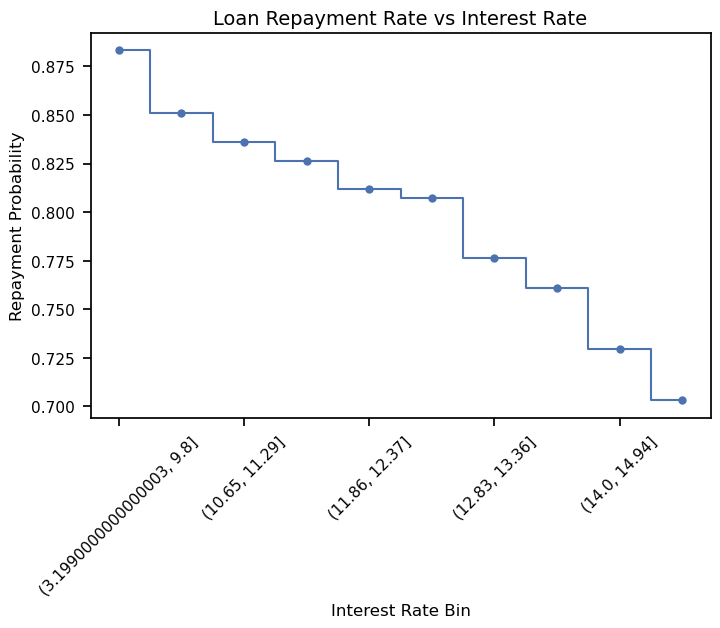

In [15]:
plt.figure()

train["interest_bin"] = pd.qcut(train["interest_rate"], q=10)

risk = train.groupby("interest_bin")["loan_paid_back"].mean()

risk.plot(
    kind="line",
    marker="o",
    drawstyle="steps-mid"
)

plt.title("Loan Repayment Rate vs Interest Rate")
plt.xlabel("Interest Rate Bin")
plt.ylabel("Repayment Probability")

plt.xticks(rotation=45)

plt.show()

In [16]:
train.drop(columns=["credit_score_bin","dti_bin","interest_bin", ], inplace=True)

In [8]:
train["loan_to_income_ratio"] = train["loan_amount"] / train["annual_income"]
test["loan_to_income_ratio"] = test["loan_amount"] / test["annual_income"]

train["interest_income_ratio"] = train["interest_rate"] / train["annual_income"]
test["interest_income_ratio"] = test["interest_rate"] / test["annual_income"]

train["credit_score_bucket"] = pd.cut(
    train["credit_score"],
    bins=[300, 580, 670, 740, 800, 850],
    labels=["Poor","Fair","Good","VeryGood","Excellent"]
)

test["credit_score_bucket"] = pd.cut(
    test["credit_score"],
    bins=[300, 580, 670, 740, 800, 850],
    labels=["Poor","Fair","Good","VeryGood","Excellent"]
)

train["dti_risk"] = pd.cut(
    train["debt_to_income_ratio"],
    bins=[0, 0.2, 0.35, 0.5, 1],
    labels=["Low","Moderate","High","VeryHigh"]
)

test["dti_risk"] = pd.cut(
    test["debt_to_income_ratio"],
    bins=[0, 0.2, 0.35, 0.5, 1],
    labels=["Low","Moderate","High","VeryHigh"]
)


C:\Users\Utkarsh Sharma\AppData\Local\Temp\ipykernel_11580\3479050109.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = train.groupby("loan_income_bin")["loan_paid_back"].mean()


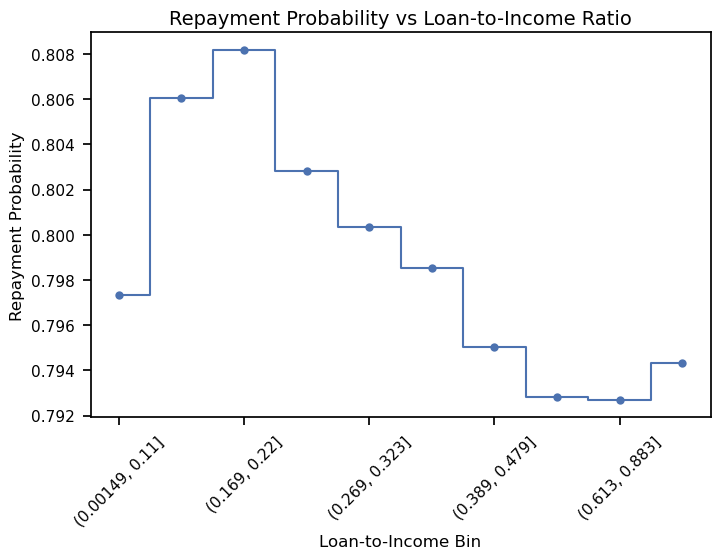

In [9]:
train["loan_income_bin"] = pd.qcut(train["loan_to_income_ratio"], q=10)

risk = train.groupby("loan_income_bin")["loan_paid_back"].mean()

plt.figure()

risk.plot(
    kind="line",
    marker="o",
    drawstyle="steps-mid"
)

plt.title("Repayment Probability vs Loan-to-Income Ratio")
plt.xlabel("Loan-to-Income Bin")
plt.ylabel("Repayment Probability")

plt.xticks(rotation=45)

plt.show()

In [10]:
num_cols = [
    "annual_income",
    "debt_to_income_ratio",
    "credit_score",
    "loan_amount",
    "interest_rate",
    "loan_to_income_ratio",
    "interest_income_ratio"
]

cat_cols = [
    "gender",
    "marital_status",
    "education_level",
    "employment_status",
    "loan_purpose",
    "grade_subgrade",
    "credit_score_bucket",
    "dti_risk",
]

In [11]:
for col in cat_cols:
    train[col] = train[col].astype(str)
    test[col] = test[col].astype(str)

In [12]:
encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

    encoders[col] = le

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   id                     593994 non-null  int64   
 1   annual_income          593994 non-null  float64 
 2   debt_to_income_ratio   593994 non-null  float64 
 3   credit_score           593994 non-null  int64   
 4   loan_amount            593994 non-null  float64 
 5   interest_rate          593994 non-null  float64 
 6   gender                 593994 non-null  int64   
 7   marital_status         593994 non-null  int64   
 8   education_level        593994 non-null  int64   
 9   employment_status      593994 non-null  int64   
 10  loan_purpose           593994 non-null  int64   
 11  grade_subgrade         593994 non-null  int64   
 12  loan_paid_back         593994 non-null  float64 
 13  loan_to_income_ratio   593994 non-null  float64 
 14  interest_income_rati

In [14]:
X = train.drop(
    columns=[
        "credit_score_bin",
        "dti_bin",
        "interest_bin",
        "loan_income_bin",
        "loan_paid_back", 
        "id"
    ],
    errors="ignore"
)

y = train["loan_paid_back"]

test_features = test.drop(columns=["id"])

In [15]:
print("Number of features:", X.shape[1])

Number of features: 15


In [16]:
train.drop(
    columns=["credit_score_bin","dti_bin","interest_bin","loan_income_bin"],
    inplace=True,
    errors="ignore"
)

corr_target = train.drop(columns=["id"]).corr()["loan_paid_back"].sort_values(ascending=False)
corr_target

loan_paid_back           1.000000
credit_score             0.234560
credit_score_bucket      0.132412
education_level          0.018781
annual_income            0.006326
marital_status          -0.000404
loan_purpose            -0.000973
loan_amount             -0.003762
loan_to_income_ratio    -0.005611
gender                  -0.007356
interest_income_ratio   -0.037154
interest_rate           -0.131184
grade_subgrade          -0.212376
dti_risk                -0.242754
debt_to_income_ratio    -0.335680
employment_status       -0.585304
Name: loan_paid_back, dtype: float64

In [17]:
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [18]:
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test_features))

In [19]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):

    print(f"\nFold {fold+1}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LGBMClassifier(
        n_estimators=1500,
        learning_rate=0.01,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc", 
        callbacks = [lgb.early_stopping(100)]
    )

    val_preds = model.predict_proba(X_val)[:,1]
    oof_preds[val_idx] = val_preds

    test_preds += model.predict_proba(test_features)[:,1] / kf.n_splits

    fold_auc = roc_auc_score(y_val, val_preds)
    print("Fold ROC-AUC:", fold_auc)


Fold 1
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1848
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Did not meet early stopping. Best iteration is:
[1500]	valid_0's auc: 0.921218	valid_0's binary_logloss: 0.24625
Fold ROC-AUC: 0.921217746980593

Fold 2
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead o

In [20]:
final_auc = roc_auc_score(y, oof_preds)

print("Overall ROC-AUC:", final_auc)

Overall ROC-AUC: 0.9202433122106926


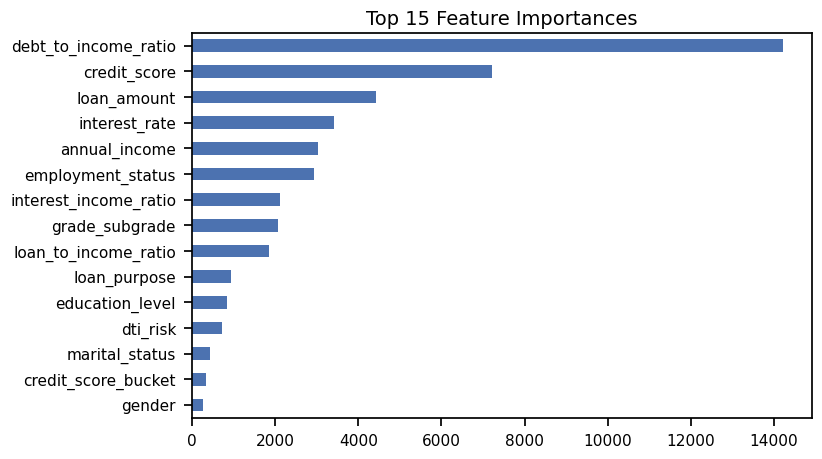

In [21]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()

importance.head(15).plot(kind="barh")

plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()

plt.savefig("loan_feature_importance.png", format = "png", dpi = 600)
plt.show()

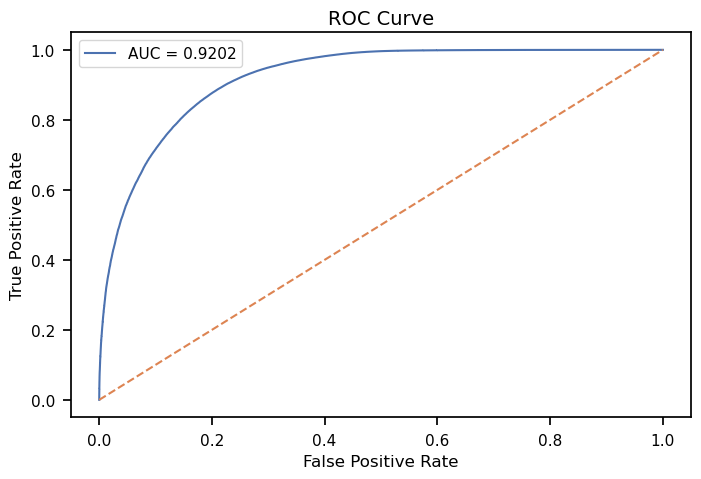

In [22]:
fpr, tpr, thresholds = roc_curve(y, oof_preds)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()
plt.savefig("loan_roc_curve.png", format = "png", dpi = 600)
plt.show()

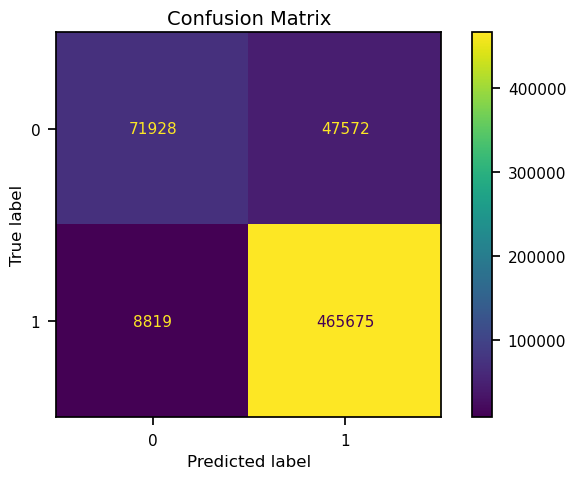

In [23]:
threshold = 0.5
pred_labels = (oof_preds >= threshold).astype(int)

cm = confusion_matrix(y, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.savefig("loan_confusion_matrix.png", format = "png", dpi = 600)
plt.show()

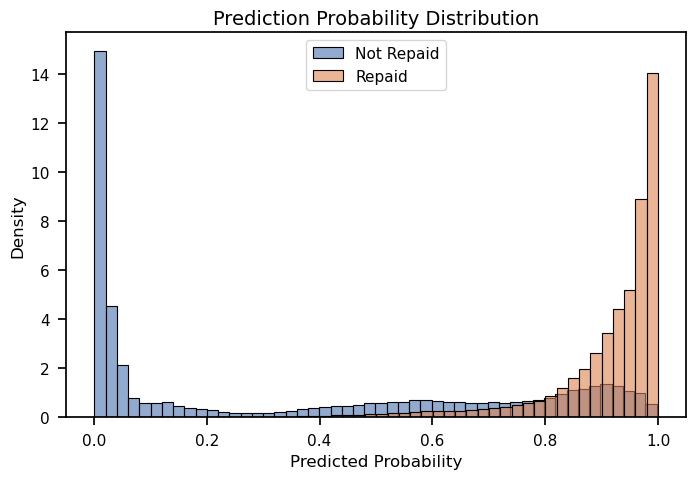

In [47]:
plt.figure()

sns.histplot(
    oof_preds[y==0],
    bins=50,
    label="Not Repaid",
    stat="density",
    alpha=0.6
)

sns.histplot(
    oof_preds[y==1],
    bins=50,
    label="Repaid",
    stat="density",
    alpha=0.6
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Predicted Probability")

plt.legend()

plt.show()

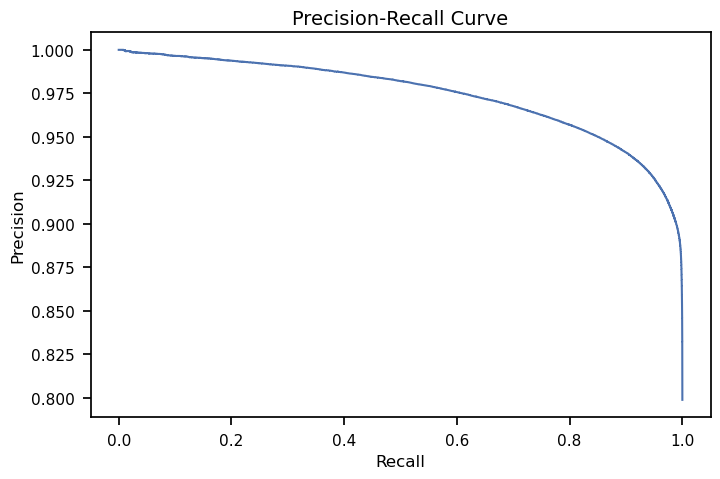

In [49]:
precision, recall, _ = precision_recall_curve(y, oof_preds)

plt.figure()

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()